#1. Import Libraries

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
print("Libraries loaded!")


Libraries loaded!


#2. Load Raw Data

In [18]:
df = pd.read_csv('TSLA.csv') 
print("Raw data loaded!")
print("Rows:", len(df), "| Columns:", len(df.columns))
df.head()

Raw data loaded!
Rows: 2956 | Columns: 7


,Date,Open,High,Low,Close,Adj Close,Volume
0,29/06/2010,3.800,5.000,3.508,4.778,4.778,93831500
1,30/06/2010,5.158,6.084,4.660,4.766,4.766,85935500
2,01/07/2010,5.000,5.184,4.054,4.392,4.392,41094000
3,02/07/2010,4.600,4.620,3.742,3.840,3.840,25699000
4,06/07/2010,4.000,4.000,3.166,3.222,3.222,34334500


#3. Frist look

In [29]:
print("Shape (rows,columns):", df.shape)
print("\nColumns name:", list(df.columns))
print("\nData types:")
print(df.dtypes)

Shape (rows,columns): (2956, 9)

Columns name: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Year', 'Price_Range']

Data types:
Date           datetime64[ns]
Open                  float64
High                  float64
Low                   float64
Close                 float64
Adj Close             float64
Volume                  int64
Year                    int32
Price_Range           float64
dtype: object


#4.Check Missing Values

In [39]:
missing = df.isnull().sum()
print("Missing values in each column:")
print(missing)
print("\nTotal missing:", missing.sum())

Missing values in each column:
Date           0
Open           0
High           0
Low            0
Close          0
Adj Close      0
Volume         0
Year           0
Price_Range    0
dtype: int64

Total missing: 0


#5. Check Duplicate Rows 

In [48]:
dup_all = df.duplicated().sum()
dup_dates = df.duplicated(subset=['Date']).sum()
print(df.info())
print("Duplicate rows:", dup_all)
print("Duplicate dates:", dup_dates)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         2956 non-null   datetime64[ns]
 1   Open         2956 non-null   float64       
 2   High         2956 non-null   float64       
 3   Low          2956 non-null   float64       
 4   Close        2956 non-null   float64       
 5   Adj Close    2956 non-null   float64       
 6   Volume       2956 non-null   int64         
 7   Year         2956 non-null   int32         
 8   Price_Range  2956 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int32(1), int64(1)
memory usage: 196.4 KB
None
Duplicate rows: 0
Duplicate dates: 0


#6.Fix data Types

In [56]:
df['Date'] = pd.to_datetime(df['Date'])

print("Date column fixed!")
print("Date range:", df['Date'].min().date(), "to", df['Date'].max().date())

Date column fixed!
Date range: 2010-06-29 to 2022-03-24


#7.Remove Duplicates and Sort

In [63]:
before = len(df)

df = df.drop_duplicates(subset=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

after = len(df)
print(f"Rown before: {before}")
print(f"Rown after:  {after}")
print(f"Removed:     {before - after}")


Rown before: 2956
Rown after:  2956
Removed:     0


#8. Logic Checks

In [69]:
before = len(df)

df = df[df['Close'] > 0]
df = df[df['Open'] > 0]
df = df[df['High'] >= df['Low']]
df = df[df['Volume'] > 0]

after = len(df)
print(f"Bad rows removed: {before - after}")
print(f"Clean rows left:  {after}")


Bad rows removed: 0
Clean rows left:  2956


#9.Create helpful New columns

In [74]:


df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
print("Date datatype:", df['Date'].dtype)

df['Year'] = df['Date'].dt.year
df['Price_Range'] = df['High'] - df['Low']
print("New columns added: Year, Price_Range")
df[['Date', 'Open', 'Close', 'Year', 'Price_Range']].head()

Date datatype: datetime64[ns]
New columns added: Year, Price_Range


,Date,Open,Close,Year,Price_Range
0,2010-06-29,3.800,4.778,2010,1.492
1,2010-06-30,5.158,4.766,2010,1.424
2,2010-07-01,5.000,4.392,2010,1.130
3,2010-07-02,4.600,3.840,2010,0.878
4,2010-07-06,4.000,3.222,2010,0.834


#10. Final Cleaning Check

In [78]:
print("=== CLEAN DATA REPORT ===")
print("Rows:", len(df))
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())
print("Negative Close prices:", (df['Close'] < 0).sum())
print("High < Low rows:", (df['High'] < df['Low']).sum())
print("\nBasic stats:")
df[['Open', 'High', 'Low', 'Close', 'Volume']].describe()

=== CLEAN DATA REPORT ===
Rows: 2956
Missing values: 0
Duplicates: 0
Negative Close prices: 0
High < Low rows: 0

Basic stats:


,Open,High,Low,Close,Volume
count,2956.000000,2956.000000,2956.000000,2956.000000,2.956000e+03
mean,138.691296,141.771603,135.425953,138.762183,3.131449e+07
std,250.044839,255.863239,243.774157,250.123115,2.798383e+07
min,3.228000,3.326000,2.996000,3.160000,5.925000e+05
25%,19.627000,20.402000,19.127500,19.615000,1.310288e+07
50%,46.656999,47.487001,45.820002,46.545000,2.488680e+07
75%,68.057001,69.357500,66.911501,68.103998,3.973875e+07
max,1234.410034,1243.489990,1217.000000,1229.910034,3.046940e+08


#11. Quick Visual Check

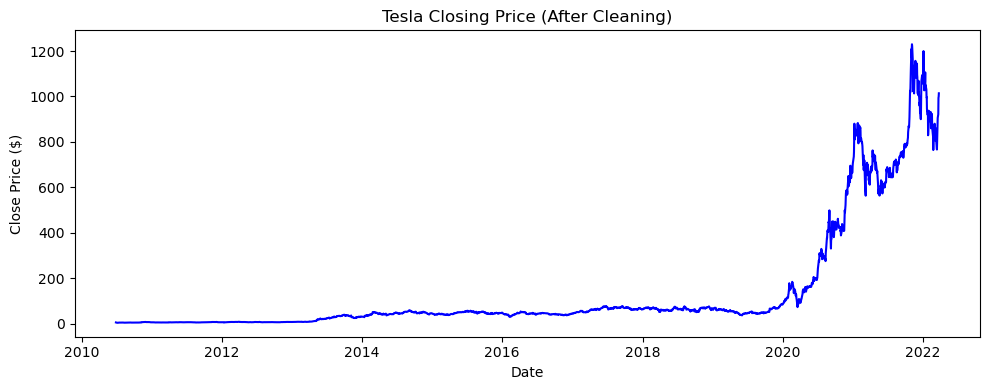

In [81]:
plt.figure(figsize=(10, 4))
plt.plot(df['Date'], df['Close'], color='blue')
plt.title('Tesla Closing Price (After Cleaning)')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.tight_layout()
plt.show()

#12. Save Clean Data

In [83]:
df.to_csv('TSLA_clean.csv', index=False)
print("Saved as TSLA_clean.csv")

Saved as TSLA_clean.csv


#13. Choose X and Y

In [84]:
X = df[['Open']]
y = df['Close']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2956, 1)
y shape: (2956,)


#14.split data train and test

In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 2364
Testing rows: 592


#15.Train simple Linear regression model

In [107]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

print("Model 1 trained!")
print(f"Formula: Close = {model1.intercept_:.2f} + {model1.coef_[0]:.2f} * Open")

Model 1 trained!
Formula: Close = 0.22 + 1.00 * Open


#16. Predict and check score

In [110]:
y_pred1 = model1.predict(X_test)
score1 = r2_score(y_test, y_pred1)

print("Model 1 (Open -> Close)")
print("R² Score:", round(score1, 4))

Model 1 (Open -> Close)
R² Score: 0.9989


#17.Plot Actual vs Predicted

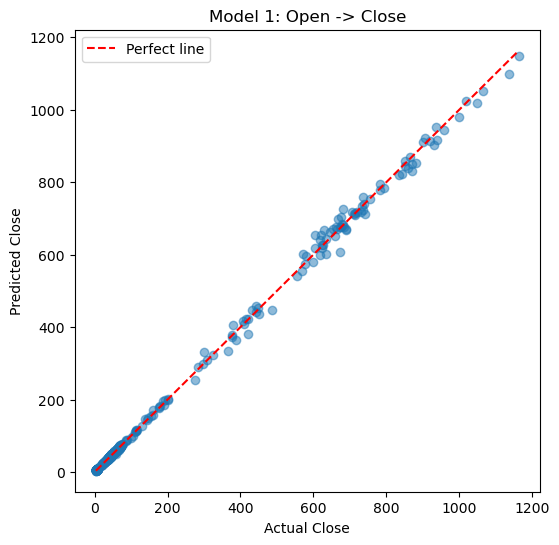

In [112]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred1, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect line')
plt.xlabel('Actual Close')
plt.ylabel('Predicted Close')
plt.title('Model 1: Open -> Close')
plt.legend()
plt.show()

#18.Train Butter Model

In [132]:
x2 = df[['Open', 'High', 'Low', 'Volume']]
y2 = df['Close']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    x2, y2, test_size=0.2, random_state=42
)
model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)
score2 = r2_score(y_test2, y_pred2)

print("Model 2 (Open, High, Low, Volume -> Close)")
print("R² Score:", round(score2, 4))

Model 2 (Open, High, Low, Volume -> Close)
R² Score: 0.9996


In [148]:
# Model 1: Open -> Close

# Input feature
X = df[['Open']]

# Target
y = df['Close']

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Linear Regression model
model1 = LinearRegression()

# Train the model
model1.fit(X_train, y_train)

# Generate predictions
y_pred1 = model1.predict(X_test)

# Calculate R² score
score1 = r2_score(y_test, y_pred1)

print("Model 1: Open -> Close")
print("R² Score:", round(score1, 4))

Model 1: Open -> Close
R² Score: 0.9989


In [149]:
# Model 2: Open + High + Low -> Close

# Input features
X2 = df[['Open', 'High', 'Low']]

# Target
y2 = df['Close']

# Split data into 80% training and 20% testing
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# Create Linear Regression model
model2 = LinearRegression()

# Train the model
model2.fit(X_train2, y_train2)

# Generate predictions
y_pred2 = model2.predict(X_test2)

# Calculate R² score
score2 = r2_score(y_test2, y_pred2)

print("Model 2: Open + High + Low -> Close")
print("R² Score:", round(score2, 4))

Model 2: Open + High + Low -> Close
R² Score: 0.9996


In [150]:
# Model 3: Open + High + Low -> Close
# Train-Test Split: 70:30

X3 = df[['Open', 'High', 'Low']]
y3 = df['Close']

# 70% training, 30% testing
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y3, test_size=0.3, random_state=42
)

# Create and train model
model3 = LinearRegression()
model3.fit(X_train3, y_train3)

# Predictions
y_pred3 = model3.predict(X_test3)

# R² score
score3 = r2_score(y_test3, y_pred3)

print("Model 3 (Open + High + Low -> Close)")
print("Train-Test Split: 70:30")
print("R² Score:", round(score3, 4))

Model 3 (Open + High + Low -> Close)
Train-Test Split: 70:30
R² Score: 0.9997


In [151]:
comparison = pd.DataFrame({
    'Model': [
        'Model 1',
        'Model 2',
        'Model 3'
    ],
    'Features': [
        'Open',
        'Open + High + Low',
        'Open + High + Low'
    ],
    'Split': [
        '80:20',
        '80:20',
        '70:30'
    ],
    'R2 Score': [
        round(score1, 4),
        round(score2, 4),
        round(score3, 4)
    ]
})

comparison

,Model,Features,Split,R2 Score
0,Model 1,Open,80:20,0.9989
1,Model 2,Open + High + Low,80:20,0.9996
2,Model 3,Open + High + Low,70:30,0.9997
